#1. Load the Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("spam.csv", encoding='latin1')

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

In [ ]:
df.columns.tolist()

['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

In [ ]:
# Keep only useful columns and rename them
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

In [ ]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#2. EDA

In [ ]:
print(df["label"].value_counts())
print()
print(f"Spam %: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")
print(f"Ham  %: {df['label'].value_counts(normalize=True)['ham']*100:.1f}%")

label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.4%
Ham  %: 86.6%


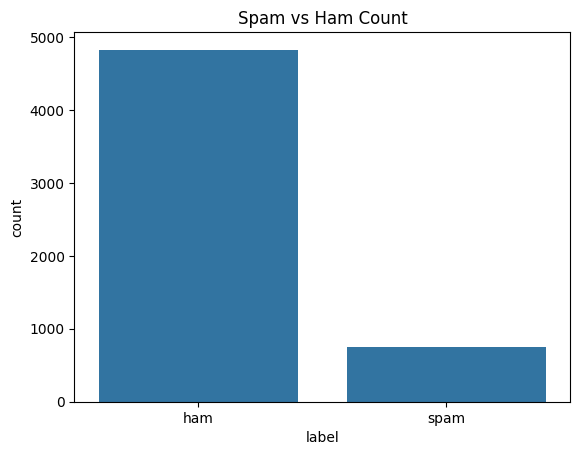

In [ ]:
sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Count")
plt.show()

In [ ]:
df["msg_length"] = df["message"].apply(len)

print(df.groupby("label")["msg_length"].mean())

label
ham      71.023627
spam    138.866131
Name: msg_length, dtype: float64


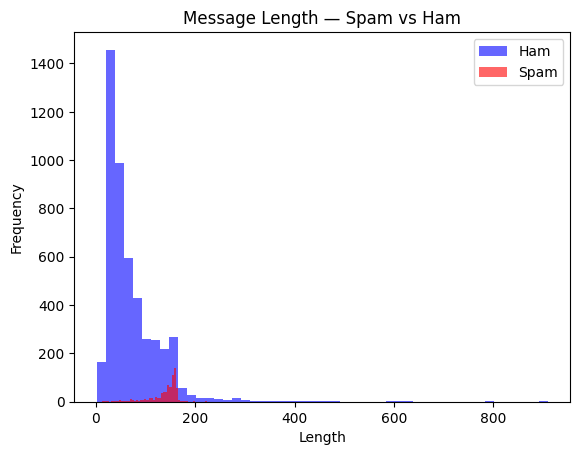

In [ ]:
df[df["label"] == "ham"]["msg_length"].plot(kind="hist", bins=50,
                                             alpha=0.6, label="Ham", color="blue")
df[df["label"] == "spam"]["msg_length"].plot(kind="hist", bins=50,
                                              alpha=0.6, label="Spam", color="red")
plt.legend()
plt.title("Message Length — Spam vs Ham")
plt.xlabel("Length")
plt.show()

In [ ]:
print("=== SPAM EXAMPLES ===")
for msg in df[df["label"] == "spam"]["message"].head(3):
    print("-", msg)
    print()

print("=== HAM EXAMPLES ===")
for msg in df[df["label"] == "ham"]["message"].head(3):
    print("-", msg)
    print()

=== SPAM EXAMPLES ===
- Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

- FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv

- WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.

=== HAM EXAMPLES ===
- Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

- Ok lar... Joking wif u oni...

- U dun say so early hor... U c already then say...



#3. Preprocessing

In [ ]:
#encode the values
df["label"] = df["label"].map({"ham": 0, "spam": 1})
print(df["label"].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()                        # lowercase everything
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = re.sub(r'[^\w\s]', '', text)        # remove punctuation
    text = text.strip()                        # remove extra spaces
    return text

df["message"] = df["message"].apply(clean_text)

print("Sample cleaned message:")
print(df["message"].iloc[0])

Sample cleaned message:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [ ]:
from sklearn.model_selection import train_test_split

X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)
print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (4457,)
Test size:  (1115,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)  # keep top 3000 words only
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("X_train shape after TF-IDF:", X_train_tfidf.shape)
print("X_test  shape after TF-IDF:", X_test_tfidf.shape)

#TF  = how often word appears in THIS message
#IDF = how rare the word is across ALL messages

#TF-IDF = TF × IDF

#"free" in spam → high TF, rare in ham → high TF-IDF score ⭐
#"the"  everywhere → high TF, not rare → low TF-IDF score

X_train shape after TF-IDF: (4457, 3000)
X_test  shape after TF-IDF: (1115, 3000)


#4. Model Training

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model 1 — Naive Bayes (best for text)
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

# Model 2 — Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)

# Model 3 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)

print("All models trained!")

All models trained!


In [ ]:
models = {"Naive Bayes": nb, "Logistic Regression": lr, "Random Forest": rf}

for name, model in models.items():
    pred = model.predict(X_test_tfidf)
    acc  = accuracy_score(y_test, pred)
    print(f"{name:20} Accuracy: {acc*100:.2f}%")

Naive Bayes          Accuracy: 97.13%
Logistic Regression  Accuracy: 96.50%
Random Forest        Accuracy: 97.40%


In [ ]:
# Naive Bayes predictions
nb_pred = nb.predict(X_test_tfidf)

print("Classification Report — Naive Bayes:")
print(classification_report(y_test, nb_pred, target_names=["Ham", "Spam"]))

Classification Report — Naive Bayes:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       965
        Spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



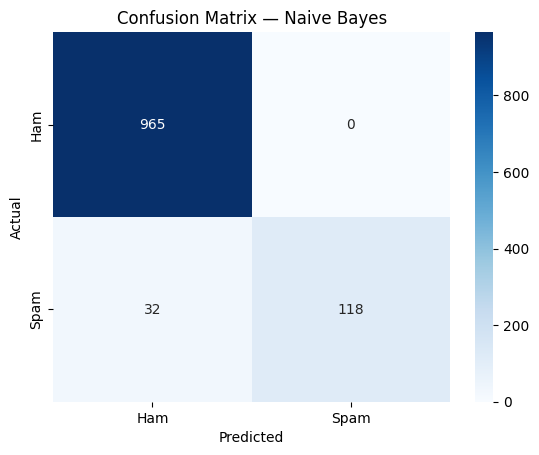

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, nb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham", "Spam"],
            yticklabels=["Ham", "Spam"])
plt.title("Confusion Matrix — Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

#5. Testing

In [ ]:
def predict_spam(message):
    # clean it same way as training data
    message = message.lower()
    message = re.sub(r'\d+', '', message)
    message = re.sub(r'[^\w\s]', '', message)

    # convert to TF-IDF
    message_tfidf = tfidf.transform([message])

    # predict
    prediction = nb.predict(message_tfidf)[0]
    probability = nb.predict_proba(message_tfidf)[0]

    label = "SPAM" if prediction == 1 else "HAM"
    confidence = probability[prediction] * 100

    print(f"Message:    {message}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.1f}%")
    print()

# Test with different messages
predict_spam("FREE entry WIN a cash prize call now to claim")
predict_spam("Hey are you coming to college tomorrow?")
predict_spam("URGENT you have won a 1000 pound prize click here")
predict_spam("Can we meet at 5pm today?")
predict_spam("Congratulations! You've been selected for a free gift")

Message:    free entry win a cash prize call now to claim
Prediction: SPAM
Confidence: 99.3%

Message:    hey are you coming to college tomorrow
Prediction: HAM
Confidence: 99.3%

Message:    urgent you have won a  pound prize click here
Prediction: SPAM
Confidence: 93.4%

Message:    can we meet at pm today
Prediction: HAM
Confidence: 98.9%

Message:    congratulations youve been selected for a free gift
Prediction: SPAM
Confidence: 77.5%

